In [2]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 87.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=e8678a962c3ec066f9a05faafeff75b21188f047904f146610e01c944d3bba31
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


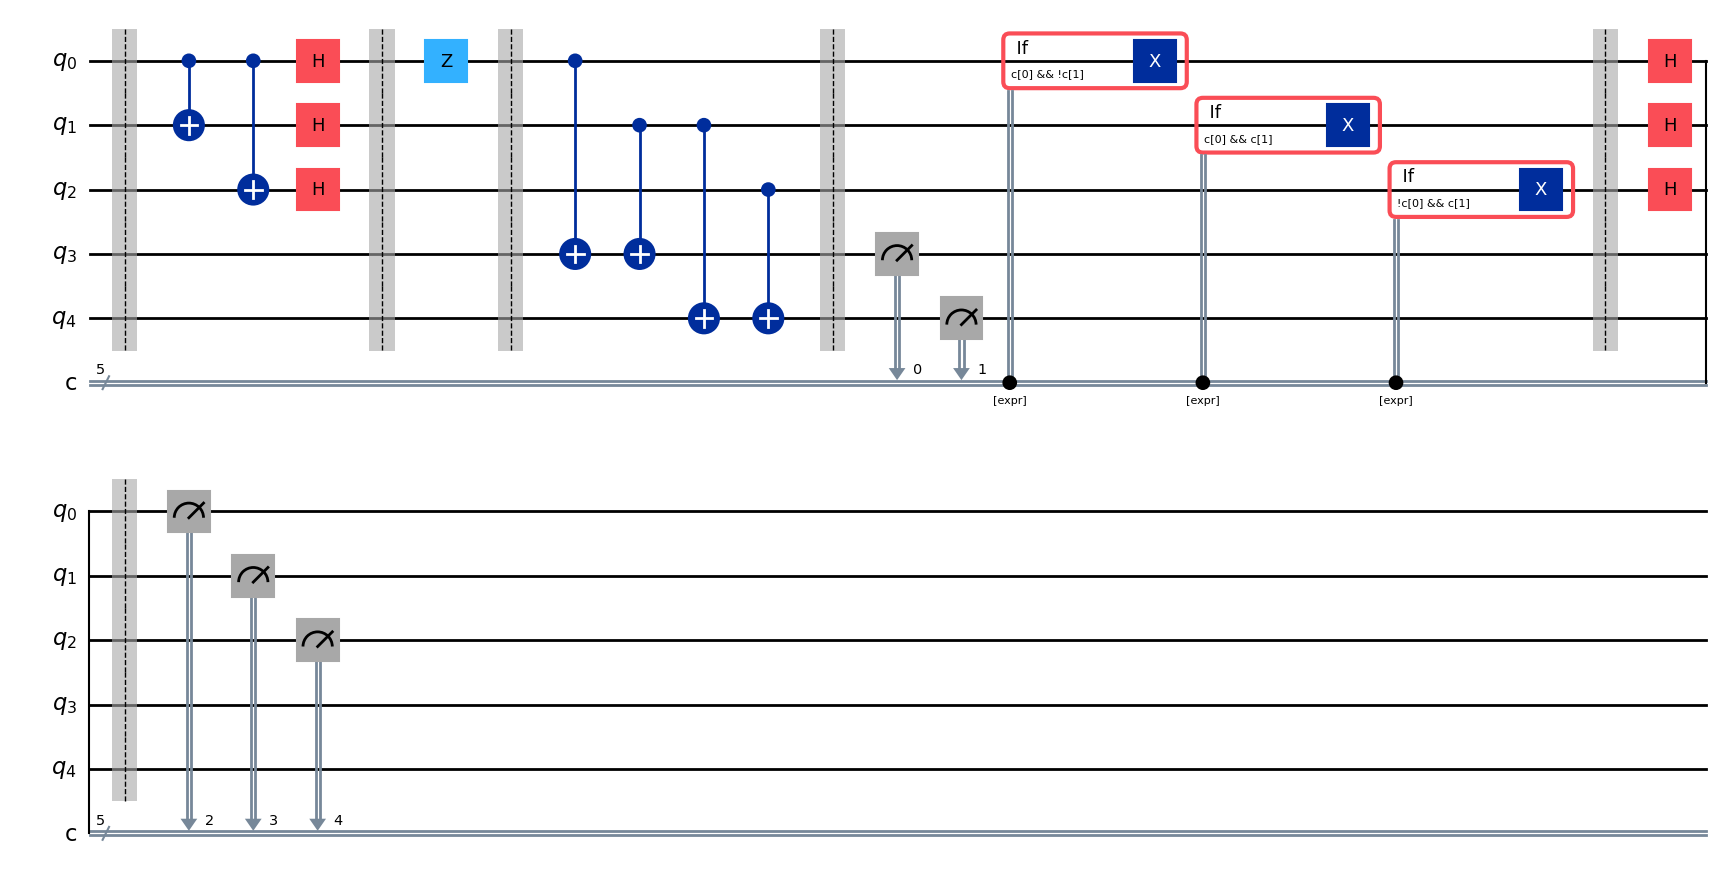

In [12]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit phase-flip error-correcting code
# A phase flip (Z error) in the Z basis becomes a bit flip (X error) in the X basis.
# So we encode into the X basis using Hadamards, correct bit flips there, then decode back.

flip = QuantumCircuit(5, 5)

# qubit 0 is the one we are trying to send
# qubits 1 and 2 are used for the encoding
# qubits 3 and 4 are used for the error syndrome
# classical bits 0 and 1 are used for the syndrome measurement
# classical bits 2, 3 and 4 are for a final measurement to check the statistics

flip.barrier()

# Encode qubit 0 onto qubits 1 and 2, then rotate all three into the X basis.
# In the X basis, |+> and |-> are the logical 0 and 1, so a phase flip (Z)
# acting on any one qubit appears as a bit flip (X) that can be detected and corrected.

flip.cx(0, 1)
flip.cx(0, 2)
flip.h(0)
flip.h(1)
flip.h(2)

flip.barrier()

# Add an error.
# A phase flip on qubit 0: try Z errors on qubits 1 or 2 as well — the code
# corrects any single phase flip.  Two simultaneous phase flips will be
# mis-corrected (same failure mode as two bit flips in the bit-flip code).
# A bit flip (X) error is not corrected by this code and will corrupt the state.

flip.z(0)   # single phase flip on qubit 0

flip.barrier()

# Syndrome measurements.
# After the Hadamard encoding a Z error shows up as an X error, so the same
# CNOT-based parity checks used in the bit-flip code detect it here.

flip.cx(0, 3)
flip.cx(1, 3)
flip.cx(1, 4)
flip.cx(2, 4)

flip.barrier()

flip.measure([3, 4], [0, 1])

# Conditional correction — identical logic to the bit-flip code because the
# syndrome still encodes which qubit suffered the (now apparent) bit flip.
# if c0 and not c1 → correct qubit 0
# if c0 and c1     → correct qubit 1
# if not c0 and c1 → correct qubit 2

with flip.if_test(expr.logic_and(flip.clbits[0], expr.logic_not(flip.clbits[1]))):
    flip.x(0)

with flip.if_test(expr.logic_and(flip.clbits[0], flip.clbits[1])):
    flip.x(1)

with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[0]), flip.clbits[1])):
    flip.x(2)

flip.barrier()

# Decode: rotate all three qubits back from the X basis to the Z basis.
# After this step the logical state is again spread across qubits 0–2 in the
# standard basis, so measuring them should reproduce the original qubit-0 statistics.

flip.h(0)
flip.h(1)
flip.h(2)

flip.barrier()

flip.measure([0, 1, 2], [2, 3, 4])

flip.draw("mpl")


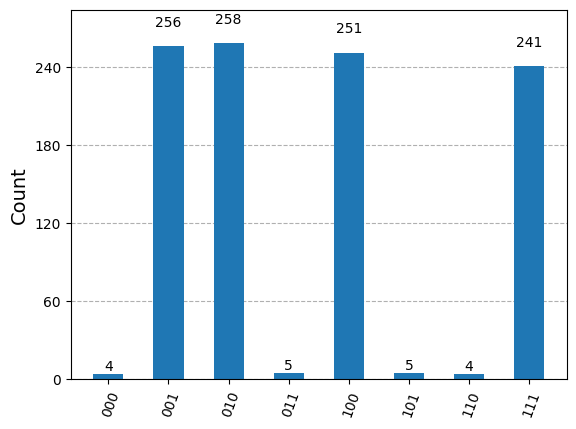

In [13]:
# Simulate and plot results

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)